In [6]:
import numpy as np
from sim_library.simulation import simulate_pulses_p_dist, simulate_pulses_p_dist_custom, simulate_pulses_single_atom, p_shift_random_walk, simulate_optical_pumping
from sim_library.sequences import gen_resonant_pm_seq, gen_offresonant_pm_seq, UpPulse, DownPulse, FreeEvolution, PulseSequence, gen_MDFE_seq, RR3_gate
from sim_library.plotting import plot_state_trajectories, plot_bloch, plot_hist, display_table, display_table_compare
from scipy.constants import hbar, pi
from sim_library.constants import k_eff, dR, m, omega_eg, kb
import matplotlib.pyplot as plt

In [ ]:
N = 10000
Temp = 15e-6

cycles = 8

rabi_freq = 2*pi*1e9
rabi_time = 2*pi/rabi_freq

time_steps = 1

RR3 = RR3_gate(rabi_freq=rabi_freq, time_steps=time_steps)

p_min = -16
p_max = 16
basis = np.arange(p_min, p_max + 1)

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
# initial_state[15] = 1
initial_state[16] = 1

initial_state = initial_state/ np.linalg.norm(initial_state)

moms_list = []
fracs_list = []

moms, fracs, mom_grid, frac_grid, _ = simulate_pulses_p_dist(pulse_seq=RR3, Temp=Temp, no_atoms=N, basis=basis, initial_state=initial_state)
moms = moms/(hbar*k_eff)

moms_list.append(moms)
fracs_list.append(fracs[-1])

moms = simulate_optical_pumping(basis=basis, init_mom_dist_grid=mom_grid, state_fracs_grid=frac_grid[-1,:,:])
moms = moms/(hbar*k_eff)

moms_list.append(moms)
fracs_list.append(np.ones(len(moms)))

for i in range(cycles-1):
    moms, fracs, mom_grid, frac_grid = simulate_pulses_p_dist_custom(pulse_seq=RR3, init_mom_dist=moms*hbar*k_eff, basis=basis, initial_state=initial_state)
    moms = moms/(hbar*k_eff)

    moms_list.append(moms)
    fracs_list.append(fracs[-1])

    moms = simulate_optical_pumping(basis=basis, init_mom_dist_grid=mom_grid, state_fracs_grid=frac_grid[-1,:,:])
    moms = moms/(hbar*k_eff)

    moms_list.append(moms)
    fracs_list.append(np.ones(len(moms)))

# fig1, ax1 = plt.subplots(figsize=(6, 7.5), layout= 'constrained')

# plot_hist(ax= ax1, mom_vals= moms, fracs= fracs, n_bins= 100, n_atoms= N, temp=Temp)

# xlims = np.arange(-10,11)
# ax1.set_xticks(xlims)
# ax1.set_xlim(-10,10)

# # fig1.tight_layout
# plt.show()

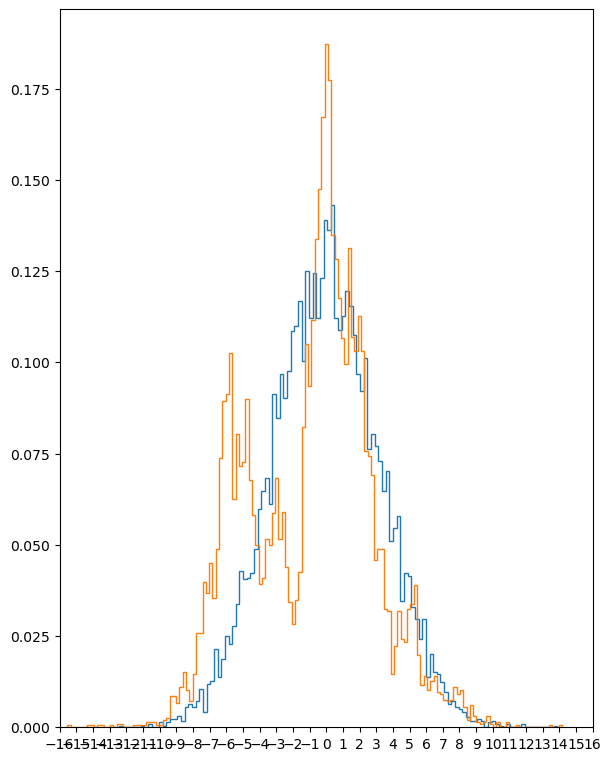

In [71]:
sigma = np.sqrt(kb*Temp/m)
initial_p_dist = m*np.random.normal(loc = 0, scale = sigma, size = N)/(hbar*k_eff)

fig1, ax1 = plt.subplots(figsize=(6, 7.5), layout= 'constrained')

final = 1
bins = 300

ax1.hist(x= initial_p_dist, bins = 120, histtype='step', density=True)
if final % 2 != 0:
    bins = 150
ax1.hist(x= moms_list[final], weights= fracs_list[final], bins = bins, histtype='step', density=True)

# xlims = np.arange(basis)
ax1.set_xticks(basis)
ax1.set_xlim(-16,16)

# fig1.tight_layout
plt.show()

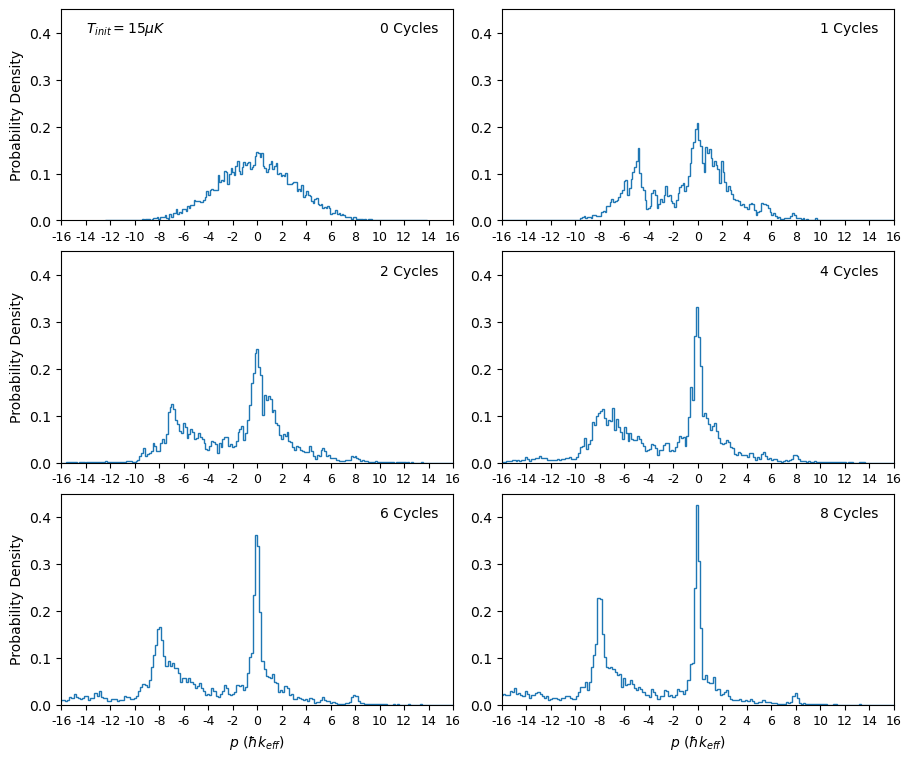

In [115]:
fig1, axes = plt.subplots(3,2, figsize=(9, 7.5), layout= 'constrained')
axes = axes.flatten()
bins = 400

index_list = [0,2,6,10,14]

axes[0].hist(x= initial_p_dist, bins = 200, histtype='step', density=True)
axes[0].set_xticks(basis[0::2], basis[0::2], fontsize = 9)
axes[0].set_xlim(basis[0],basis[-1])
axes[0].set_yticks(np.linspace(0,0.4,5))
axes[0].set_ylim(0,0.45)
axes[0].set_ylabel('Probability Density')
    

for i in range(1,6):
    axes[i].hist(x = moms_list[index_list[i-1]+1], weights= fracs_list[index_list[i-1]+1], bins = bins, histtype='step', density=True)
    axes[i].set_xticks(basis[0::2], basis[0::2], fontsize = 9)
    axes[i].set_xlim(basis[0],basis[-1])
    axes[i].set_yticks(np.linspace(0,0.4,5))
    axes[i].set_ylim(0,0.45)


axes[4].set_xlabel(r'$p$ ($\hbar k_{eff}$)')
axes[5].set_xlabel(r'$p$ ($\hbar k_{eff}$)')
axes[0].set_ylabel('Probability Density')
axes[2].set_ylabel('Probability Density')
axes[4].set_ylabel('Probability Density')

axes[0].text(10,0.4,r'0 Cycles')
axes[1].text(10,0.4,r'1 Cycles')
axes[2].text(10,0.4,r'2 Cycles')
axes[3].text(10,0.4,r'4 Cycles')
axes[4].text(10,0.4,r'6 Cycles')
axes[5].text(10,0.4,r'8 Cycles')

axes[0].text(-14,0.4,r'$T_{init}=15\mu K$')




# axes[0].text(r'0 Cycles')

plt.show()


In [112]:
moms_list.insert(0, initial_p_dist)
fracs_list.insert(0, np.ones(len(initial_p_dist)))

In [118]:
np.savez('data/algorithmic cooling/27_2_26_15_moms_list_muK_10000atoms_f3_8cycles', *moms_list)
np.savez('data/algorithmic cooling/27_2_26_15_fracs_list_muK_10000atoms_f3_8cycles', *fracs_list)

In [119]:
import h5py